# Diabetic Retinopathy Detection
## Computer Vision Project — UC3M

**Task:** Binary classification — No DR (label 0) vs. DR present (label 1)  
**Evaluation metric:** ROC-AUC  
**Architecture:** 
**Key design:** Green channel (no CLAHE) · Weighted sampling · Simple architecture as low-complexity baseline  
**Best validation AUC achieved:** 0.6231

> **Note:** this is the weakest model in the ensemble and serves as a lower bound for custom architecture performance. Its limitations highlight why more expressive architectures (SmallVGG, SmallResNet) are needed for this task.

## 1. Imports and Configuration

Standard deep learning stack (PyTorch, torchvision, skimage, OpenCV, scikit-learn) with fixed random seed (`seed=42`) for reproducibility across Python, NumPy, and PyTorch.

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models
import torch.nn.functional as F

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## 2. Dataset — `RetinopathyDataset`

Custom PyTorch `Dataset` with:
- **Right-eye mirroring** (`eye==1` → horizontal flip) to ensure consistent anatomical orientation across all images
- **Binary label conversion** (`label > 0` → DR-positive) collapsing the 0–4 severity scale to a binary problem
- Optional random subset sampling (`maxSize`) for debugging

In [2]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Custom Preprocessing Transforms

Domain-specific transforms for fundus images:

- **`CropByEye`:** uses OpenCV thresholding to detect and crop the eye bounding box, removing uninformative black background pixels and standardizing the retinal region across different imaging setups
- **`Rescale`:** proportionally resizes (aspect-ratio preserving) to the target size before center cropping
- **`ToTensor`:** H×W×C → C×H×W conversion to PyTorch tensor format

### `GreenChannel`
Extracts the green channel and replicates it to 3 channels (for compatibility with 3-input architectures). Unlike `GreenChannelCLAHE`, no contrast enhancement is applied here — this is a simpler baseline preprocessing to isolate the effect of the architecture.

In [3]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Augmentation is applied **only during training** to increase effective dataset diversity:
- **Random horizontal flip (p=0.5):** valid since images are eye-orientation-normalized
- **Random rotation (±5–10°):** simulates natural variation in camera alignment

In [4]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [5]:
class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __call__(self, sample):
        from PIL import Image

        image, label = sample['image'], sample['label']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        image = np.array(pil).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [6]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [7]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [8]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

In [9]:
class GreenChannel(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']

        # Ensure float [0,1]
        if image.dtype != np.float32:
            image = image.astype(np.float32)
        if image.max() > 1.0:
            image = image / 255.0

        # Extract green channel
        green = image[:, :, 1]

        # Stack to 3 channels (for pretrained models)
        image = np.stack([green, green, green], axis=-1)

        return {'image': image, 'label': label}
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']

        # Ensure uint8 in [0, 255]
        if image.dtype != np.uint8:
            if image.max() <= 1.0:
                image = (image * 255).astype(np.uint8)
            else:
                image = image.astype(np.uint8)

        # Convert RGB -> LAB
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

        # Apply CLAHE to L channel
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        l = clahe.apply(l)

        # Merge back and convert LAB -> RGB
        lab = cv2.merge((l, a, b))
        image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        # Back to float [0,1] for the rest of the pipeline
        image = image.astype(np.float32) / 255.0

        return {'image': image, 'label': label}

## 5. Transform Pipeline

Standard deterministic pipeline with green channel extraction. **No CLAHE** is applied here, in contrast to custom1 and custom3, providing a controlled ablation: the performance difference partly reflects the benefit of CLAHE contrast enhancement.

In [10]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),         # or a bit larger like 240/256
    CenterCrop(224),
    GreenChannel(),
    TVAugment(),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

val_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    CenterCrop(224),
    GreenChannel(),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

## 6. Data Loaders with Weighted Sampling

`WeightedRandomSampler` addresses the ~73/27 class imbalance by oversampling the minority (DR) class during training batches. Per-sample weights are computed as the inverse of their class frequency.

In [11]:
from torch.utils.data import WeightedRandomSampler, DataLoader
import torch
import os

data_dir='/kaggle/input/datasets/m100561546/dataset/data'

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform
)

# Use the same binary labels as __getitem__
labels = (train_dataset.dataset["label"] > 0).astype(int).tolist()

# Count class frequencies
labels_tensor = torch.tensor(labels, dtype=torch.long)
class_counts = torch.bincount(labels_tensor)

# Inverse frequency weights
class_weights = 1.0 / class_counts.float()

# Per-sample weights
sample_weights = [class_weights[label].item() for label in labels]

# Sampler
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=weighted_sampler,
    shuffle=False
)

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 7. Model Architecture


```
Input (3×224×224) [green channel ×3]
  → Conv1(3→6, kernel=5) + ReLU + AvgPool2d(2)   [→ 6×110×110]
  → Conv2(6→16, kernel=5) + ReLU + AvgPool2d(2)  [→ 16×53×53]
  → Flatten                                        [→ 44944]
  → FC(44944→120) + ReLU
  → FC(120→84) + ReLU
  → FC(84→1)
```


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class custom2(nn.Module):
    def __init__(self, img_size=224):
        super(custom2, self).__init__()

        # feature extractor
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)      # RGB input instead of grayscale
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2) 
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        # Compute flatten size automatically for your image size
        with torch.no_grad():
            x = torch.zeros(1, 3, img_size, img_size)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            flat_dim = x.flatten(1).shape[1]

        # classifier
        self.fc1 = nn.Linear(flat_dim, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)   # binary classification

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = custom2().to(device)

## 8. Loss Function, Optimizer, and Scheduler

- **Loss:** `BCEWithLogitsLoss` — standard binary cross-entropy (class imbalance handled via WeightedRandomSampler)
- **Optimizer:** `Adam` with `lr=1e-4`
- **Scheduler:** `StepLR(step_size=10, gamma=0.1)` — reduces LR by ×10 every 10 epochs


In [13]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## 10. Training Loop with Early Stopping

Standard training procedure with:
- **AUC-based early stopping (patience=10):** halts training if val AUC does not improve for 10 epochs, preventing overfitting on this small dataset
- **Best-weight checkpointing:** model from highest val AUC epoch is saved to disk and restored at end
- **ReduceLROnPlateau scheduler:** some custom models use adaptive LR reduction triggered by validation AUC plateau, rather than fixed decay

In [14]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_model_resnet50.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step()

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

## 11. Training

Then nets limited capacity means it saturates quickly. The training curves show the model plateauing at AUC ~0.62 — fundamentally limited by the shallow architecture's inability to learn the complex spatial patterns of DR lesions.

In [15]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.6952 | Val Loss: 0.7163 | AUC: 0.5496
New best model!

Epoch 2/100


Train Loss: 0.6919 | Val Loss: 0.6653 | AUC: 0.5599
New best model!

Epoch 3/100


Train Loss: 0.6902 | Val Loss: 0.6625 | AUC: 0.5657
New best model!

Epoch 4/100


Train Loss: 0.6865 | Val Loss: 0.6624 | AUC: 0.5648
Patience: 1/10

Epoch 5/100


...

Train Loss: 0.6687 | Val Loss: 0.6787 | AUC: 0.6102
Patience: 6/10

Epoch 18/100


Train Loss: 0.6728 | Val Loss: 0.6759 | AUC: 0.6140
Patience: 7/10

Epoch 19/100


Train Loss: 0.6729 | Val Loss: 0.6755 | AUC: 0.6174
Patience: 8/10

Epoch 20/100


Train Loss: 0.6661 | Val Loss: 0.6869 | AUC: 0.6164
Patience: 9/10

Epoch 21/100


Train Loss: 0.6732 | Val Loss: 0.6847 | AUC: 0.6161
Patience: 10/10
Early stopping triggered


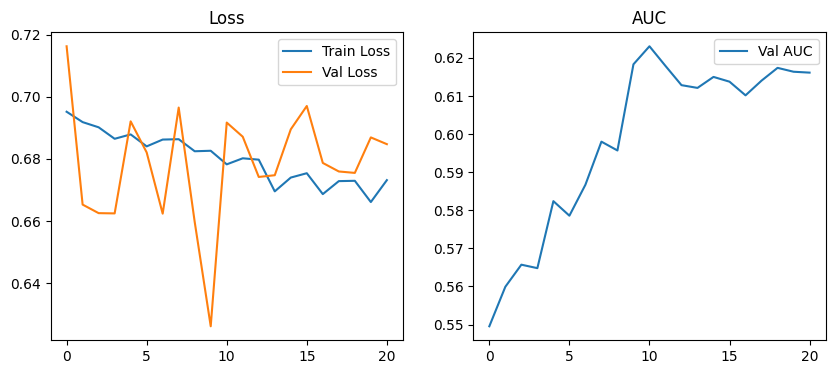

In [16]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## 12. Evaluation on Validation Set

Final validation AUC and accuracy are computed. The low AUC (~0.62) confirms that LeNet's 5-layer architecture is insufficient for detecting the subtle, spatially distributed patterns of diabetic retinopathy in high-resolution fundus images. This result motivates the deeper architectures used in custom1 and custom3.

In [17]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)

            outputs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    outputs_all = np.array(outputs_all)
    labels_all = np.array(labels_all)

    auc = roc_auc_score(labels_all, outputs_all)

    # Convert to binary predictions
    preds = (outputs_all > 0.5).astype(int)
    acc = accuracy_score(labels_all, preds)

    return auc, acc

In [18]:
val_auc, val_acc = evaluate_model(model, val_loader)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation AUC: 0.6231
Validation Accuracy: 0.4920


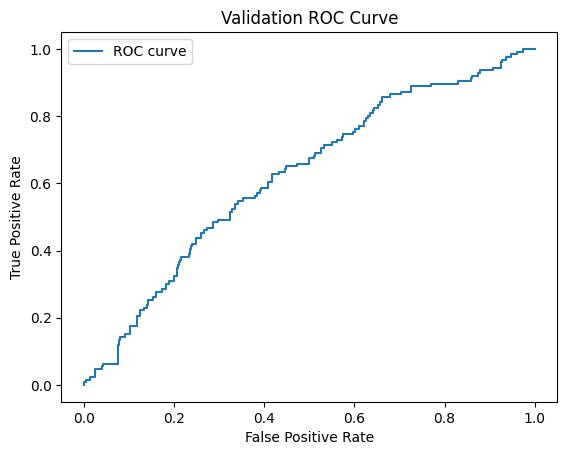

In [19]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = torch.sigmoid(model(inputs).squeeze())

            outputs_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels_all, outputs_all)

    plt.plot(fpr, tpr, label="ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()
plot_roc(model, val_loader)

## 13. Test Set Predictions

Standard prediction without TTA (the model's low capacity makes TTA less impactful). Predictions are saved to CSV for the ensemble notebook.

In [20]:
def predict(model, loader):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            preds = torch.sigmoid(model(inputs).squeeze())
            outputs.extend(preds.cpu().numpy())

    return np.array(outputs)

test_outputs = predict(model, test_loader)

In [21]:
import csv

with open("convnext_tiny_baseline.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])